In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from setup import train, device, train_test_split_path, accuracy, plot_losses, Image_dataset
X_train_path, X_test_path, X_eval_path, y_train, y_test, y_eval = train_test_split_path()

Usando dispositivo: cuda


### Simple CNN

In [2]:
class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        # (B,1 ,80,3001) → Conv → LeakyReLU → Pool → (B,32,40,1500)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        # (B,32,40,1500) → Conv → LeakyReLU → Pool → (B,64,20,750)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        # (B,64,20,750) → Conv → LeakyReLU → Pool → (B,128,10,375)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        # Global pooling to collapse spatial dims → (B,128,1,1)
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        self.fc       = nn.Linear(128, 10)

    def forward(self, x):
        x = x.unsqueeze(1) # add channel dimension for Conv2d (B,80,3001) -> (B,1,80,3001)

        x = F.leaky_relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = F.leaky_relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        x = F.leaky_relu(self.conv3(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        x = self.global_pool(x)
        
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

In [3]:
# Definimos hiperparámetros
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
HIDDEN_SIZE = 32

#### Mel

In [4]:
X_train = np.load('../Data/X_test_mel.npy') 
X_test = np.load('../Data/X_test_mel.npy') 

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = Image_dataset(X_train, y_train)
test_dataset = Image_dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 180 pares
Testeo: 180 pares


{'input': tensor([[-17.9474, -13.7789, -23.3506,  ..., -20.5041, -17.5524, -21.1973],
         [-16.9803, -12.2452, -21.5641,  ..., -21.2815, -14.0695, -21.4555],
         [-17.9659, -16.9527, -22.6373,  ..., -14.2629, -12.4558, -18.5876],
         ...,
         [-72.8470, -80.0000, -80.0000,  ..., -67.5897, -67.9812, -71.3745],
         [-75.1064, -80.0000, -80.0000,  ..., -77.1519, -76.6741, -79.6736],
         [-76.0252, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (80, 3001),
 'target_length': 10}

In [5]:
# Inicializa el modelo 
model = CNN1().to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

#### Entrenamiento del modelo #####
BATCH_SIZE = 8
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses_mel, val_losses_mel = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Modelo creado con 93962 parámetros
Iniciando entrenamiento...
--------------------------------------------------
Época 5/20
  Pérdida Entrenamiento: 2.3425
  Pérdida Testeo: 2.4396
  Empeorando
Época 10/20
  Pérdida Entrenamiento: 2.3145
  Pérdida Testeo: 2.3542
  Empeorando
Época 15/20
  Pérdida Entrenamiento: 2.2842
  Pérdida Testeo: 2.3547
  Empeorando
Época 20/20
  Pérdida Entrenamiento: 2.2387
  Pérdida Testeo: 2.4923
  Empeorando
Entrenamiento completado! Tiempo total: 35.71 segundos
--------------------------------------------------
Accuracy del modelo con los datos de testeo: 0.06


In [6]:
#torch.save(model.state_dict(), "../Models/cnn_modelo1_mel.pth")

#### Mfcc

In [7]:
X_train = np.load('../Data/X_test_mfcc.npy') 
X_test = np.load('../Data/X_test_mfcc.npy') 

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = Image_dataset(X_train, y_train)
test_dataset = Image_dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 180 pares
Testeo: 180 pares


{'input': tensor([[-0.8828, -0.7779, -0.6684,  ...,  0.0711,  0.2029,  0.0720],
         [ 1.2066,  1.4096,  1.5490,  ...,  0.0583,  0.2286,  0.3627],
         [-1.5820, -1.3850, -1.0694,  ...,  0.0878,  0.2417,  0.3653],
         ...,
         [ 0.0987,  0.0987,  0.0987,  ...,  0.6276,  0.6276,  0.6276],
         [ 0.5222,  0.5222,  0.5222,  ..., -1.0187, -1.0187, -1.0187],
         [-0.3110, -0.3110, -0.3110,  ...,  1.1178,  1.1178,  1.1178]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (60, 1288),
 'target_length': 10}

In [8]:
# Inicializa el modelo 
model = CNN1().to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

#### Entrenamiento del modelo #####
BATCH_SIZE = 8
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses_mfcc, val_losses_mfcc = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Modelo creado con 93962 parámetros
Iniciando entrenamiento...
--------------------------------------------------
Época 5/20
  Pérdida Entrenamiento: 2.2852
  Pérdida Testeo: 2.3326
  Empeorando
Época 10/20
  Pérdida Entrenamiento: 2.2820
  Pérdida Testeo: 2.3330
  Empeorando
Época 15/20
  Pérdida Entrenamiento: 2.2758
  Pérdida Testeo: 2.3320
  Empeorando
Época 20/20
  Pérdida Entrenamiento: 2.2656
  Pérdida Testeo: 2.3305
  Empeorando
Entrenamiento completado! Tiempo total: 12.72 segundos
--------------------------------------------------
Accuracy del modelo con los datos de testeo: 0.14


In [9]:
#torch.save(model.state_dict(), "../Models/cnn_modelo1_mfcc.pth")

#### Cqt

In [10]:
X_train = np.load('../Data/X_test_cqt.npy') 
X_test = np.load('../Data/X_test_cqt.npy') 

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = Image_dataset(X_train, y_train)
test_dataset = Image_dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 180 pares
Testeo: 180 pares


{'input': tensor([[-26.3957, -26.6707, -27.2908,  ..., -21.6677, -21.4570, -21.6629],
         [-21.4455, -21.0779, -21.0258,  ..., -19.5329, -20.2439, -21.2782],
         [-18.7445, -17.8251, -17.2982,  ..., -25.0518, -26.2675, -26.7663],
         ...,
         [-39.1570, -40.4309, -40.8441,  ..., -36.0859, -29.0912, -34.8054],
         [-39.7874, -41.4540, -41.3924,  ..., -28.8281, -37.6745, -37.6822],
         [-42.5130, -45.3808, -43.6282,  ..., -30.8793, -37.7639, -44.4557]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (84, 1290),
 'target_length': 10}

In [11]:
# Inicializa el modelo 
model = CNN1().to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

#### Entrenamiento del modelo #####
BATCH_SIZE = 8
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses_cqt, val_losses_cqt = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Modelo creado con 93962 parámetros
Iniciando entrenamiento...
--------------------------------------------------
Época 5/20
  Pérdida Entrenamiento: 2.2863
  Pérdida Testeo: 2.3322
  Empeorando
Época 10/20
  Pérdida Entrenamiento: 2.2920
  Pérdida Testeo: 2.3290
  Empeorando
Época 15/20
  Pérdida Entrenamiento: 2.2505
  Pérdida Testeo: 2.3946
  Empeorando
Época 20/20
  Pérdida Entrenamiento: 2.2389
  Pérdida Testeo: 2.4728
  Empeorando
Entrenamiento completado! Tiempo total: 17.17 segundos
--------------------------------------------------
Accuracy del modelo con los datos de testeo: 0.06


In [12]:
#torch.save(model.state_dict(), "../Models/cnn_modelo1_cqt.pth")

#### Wav2Vec2

In [13]:
X_train = np.load('../Data/X_test_wav2vec2.npy') 
X_test = np.load('../Data/X_test_wav2vec2.npy') 

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = Image_dataset(X_train, y_train)
test_dataset = Image_dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 180 pares
Testeo: 180 pares


{'input': tensor([[ 7.5144e-03,  3.1395e-01, -1.4196e-01,  ..., -6.0616e-02,
          -2.0563e-01,  1.2313e+00],
         [ 6.2169e-03,  2.9040e-01, -1.4545e-01,  ..., -5.6873e-03,
          -1.7907e-01,  1.2737e+00],
         [ 5.0094e-02,  2.5019e-01, -1.5639e-01,  ...,  6.0412e-04,
          -2.5280e-01,  1.1658e+00],
         ...,
         [-1.9071e-02,  2.0465e-01, -1.1574e-01,  ..., -1.8211e-01,
          -1.6709e-01,  1.3782e+00],
         [-1.8530e-02,  1.4451e-01, -1.5639e-01,  ..., -2.4901e-01,
          -2.7566e-01,  1.4784e+00],
         [ 2.1325e-02,  4.9704e-02, -1.6911e-01,  ..., -1.6256e-01,
          -1.9998e-01,  1.3678e+00]], device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (1496, 768),
 'target_length': 10}

In [14]:
# Inicializa el modelo 
model = CNN1().to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

#### Entrenamiento del modelo #####
BATCH_SIZE = 4
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses_wav2vec2, val_losses_wav2vec2 = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Modelo creado con 93962 parámetros
Iniciando entrenamiento...
--------------------------------------------------
Época 5/20
  Pérdida Entrenamiento: 2.2876
  Pérdida Testeo: 2.3185
  Empeorando
Época 10/20
  Pérdida Entrenamiento: 2.2855
  Pérdida Testeo: 2.3208
  Empeorando
Época 15/20
  Pérdida Entrenamiento: 2.2845
  Pérdida Testeo: 2.3218
  Empeorando
Época 20/20
  Pérdida Entrenamiento: 2.2838
  Pérdida Testeo: 2.3226
  Empeorando
Entrenamiento completado! Tiempo total: 160.02 segundos
--------------------------------------------------
Accuracy del modelo con los datos de testeo: 0.10


In [15]:
#torch.save(model.state_dict(), "../Models/cnns_modelo1_wav2vec2.pth")

#### Summary plot

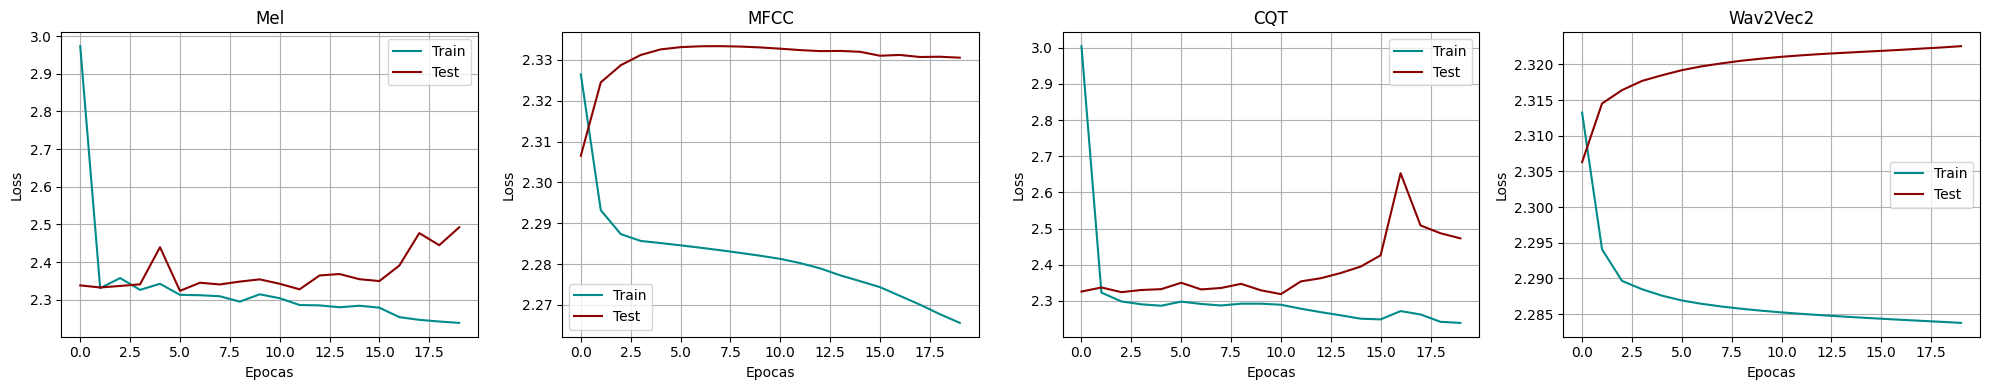

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

plot_losses(train_losses_mel, val_losses_mel, axes[0], title='Mel')
plot_losses(train_losses_mfcc, val_losses_mfcc, axes[1], title='MFCC')
plot_losses(train_losses_cqt, val_losses_cqt, axes[2], title='CQT')
plot_losses(train_losses_wav2vec2, val_losses_wav2vec2, axes[3], title='Wav2Vec2')
#for ax in axes:
#    ax.set_ylim(-0.1, 2.5)
plt.tight_layout()
plt.show()